
FIRST 5 ROWS
   Order_ID Customer_Name Region Product_Category    Sales   Profit  Quantity  \
0         1         Grace   West      Electronics  2650.91  2361.10         7   
1         2         Grace   East         Clothing  8795.59  1843.23         3   
2         3           Bob   West        Groceries  9446.97   102.26         1   
3         4         Frank  North        Groceries  1207.56  1621.85        10   
4         5         David   West         Clothing  5104.63  2377.01        19   

   Discount  
0      0.22  
1      0.01  
2      0.15  
3      0.02  
4      0.19  

DATASET SHAPE
(102, 8)

COLUMN NAMES
Index(['Order_ID', 'Customer_Name', 'Region', 'Product_Category', 'Sales',
       'Profit', 'Quantity', 'Discount'],
      dtype='object')

DATASET INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 102 entries, 0 to 101
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Order_ID          102

/tmp/ipykernel_9384/3672839247.py:30: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mean(), inplace=True)
/tmp/ipykernel_9384/3672839247.py:33: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try us

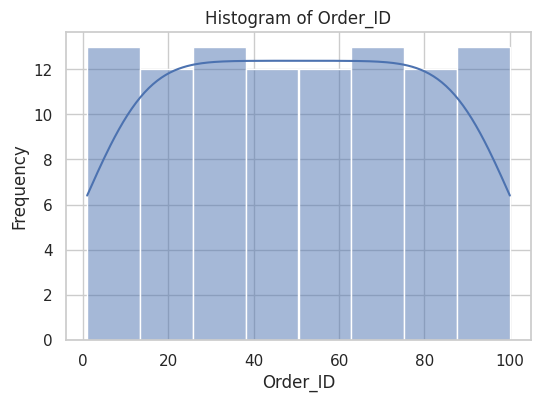

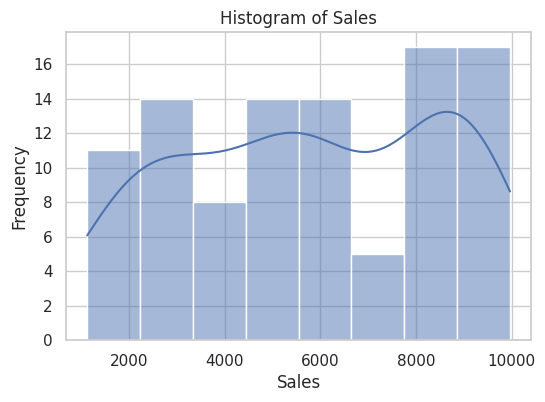

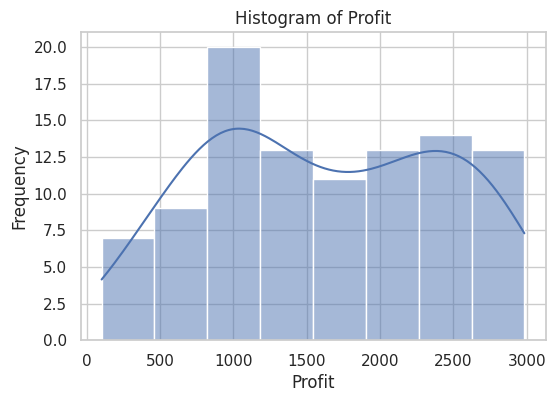

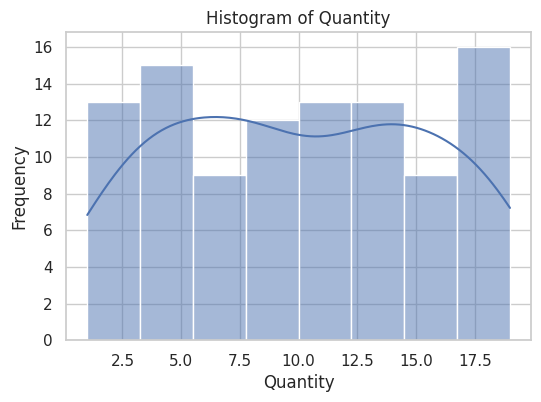

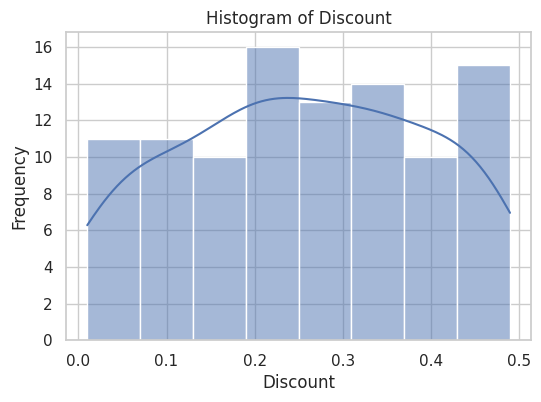

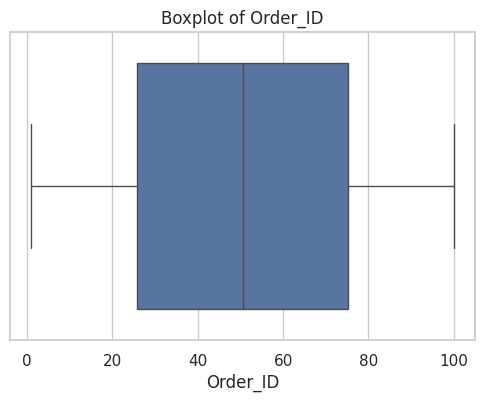

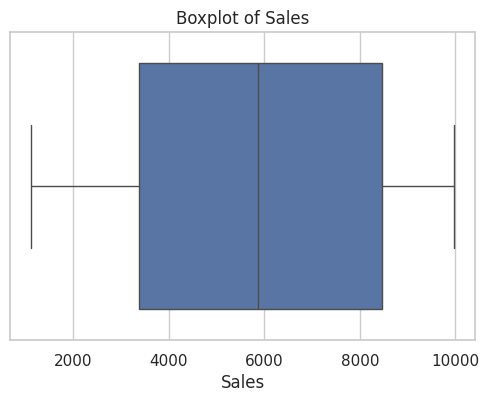

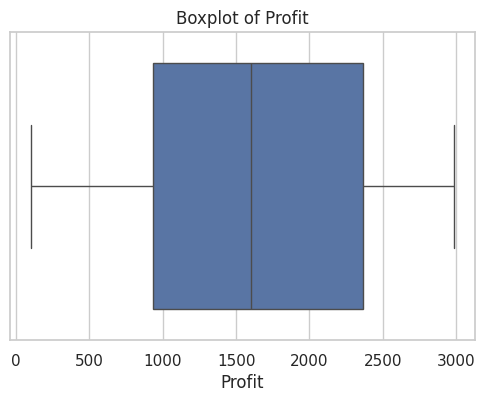

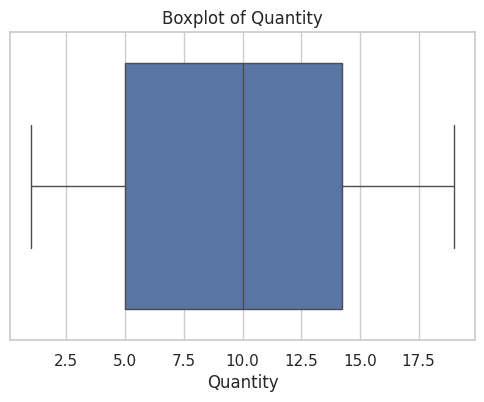

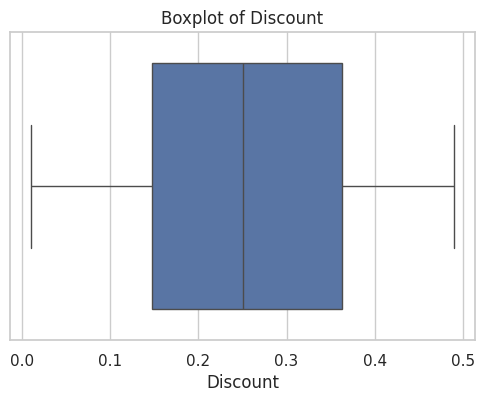

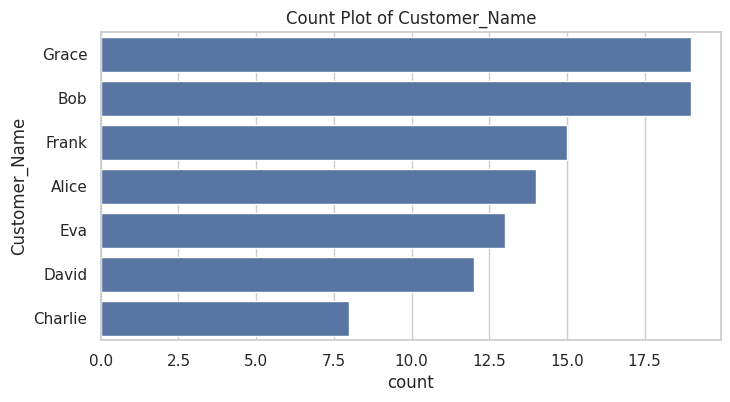

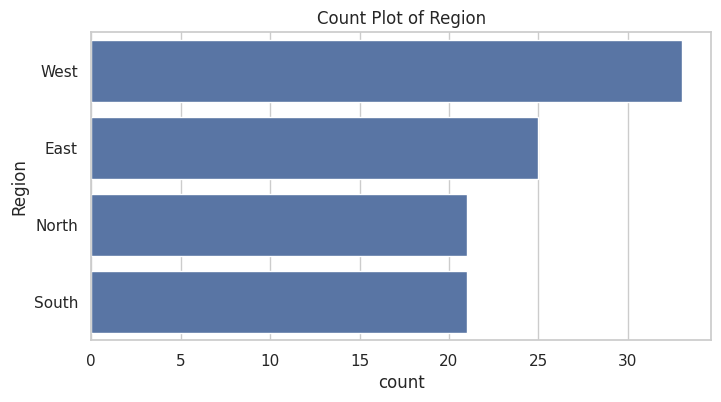

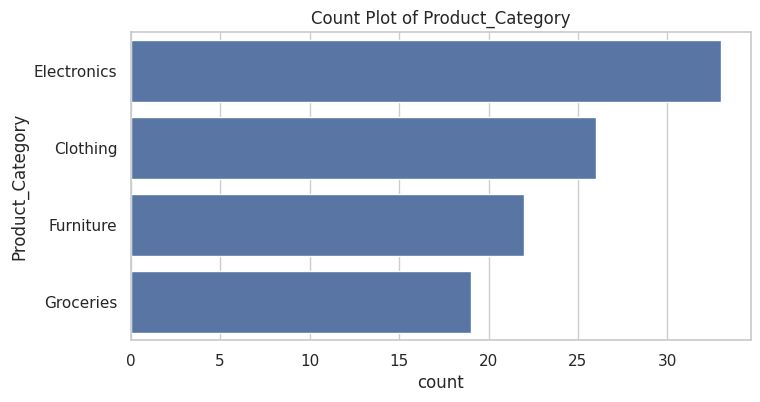

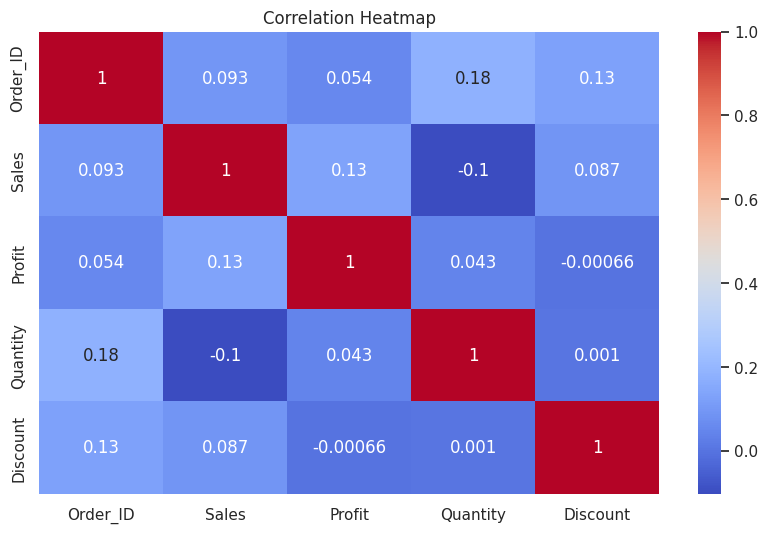

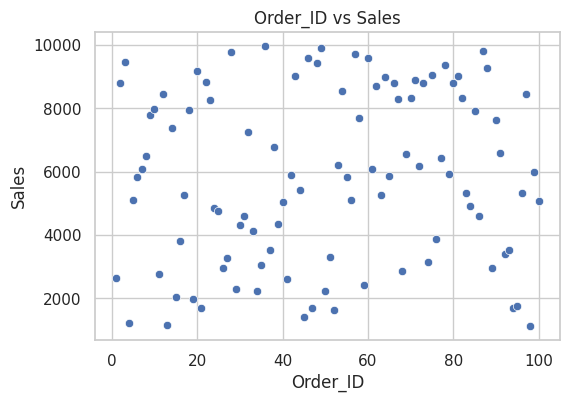

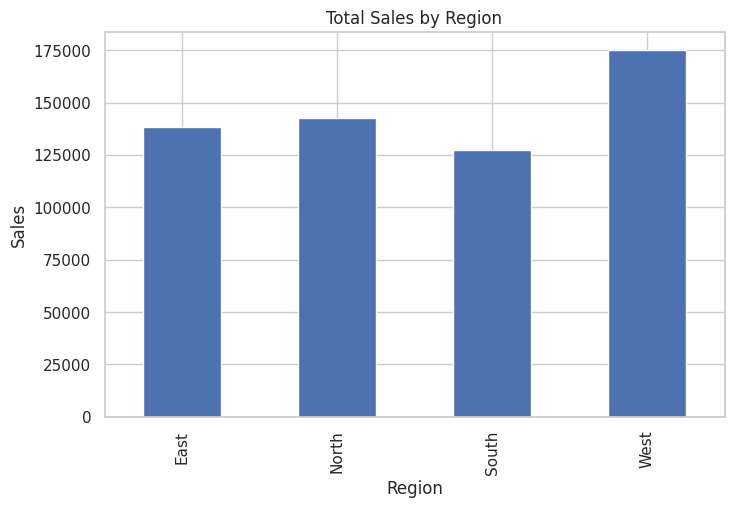

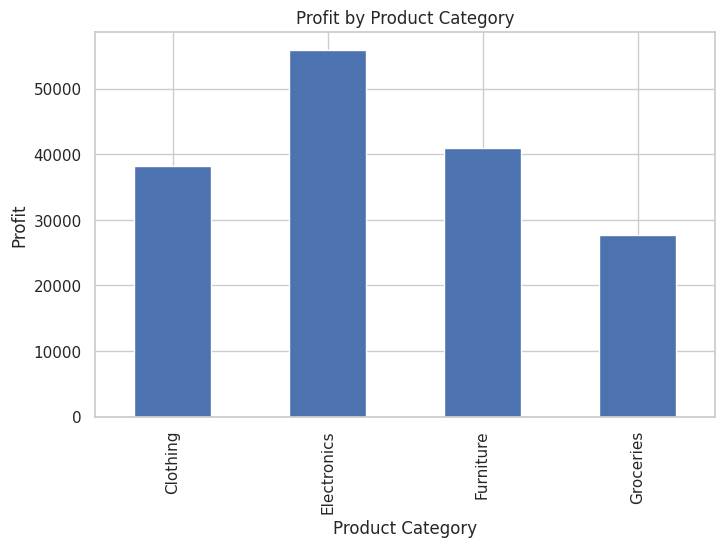


Analysis for Order_ID
Mean : 50.5
Median : 50.5
Maximum : 100
Minimum : 1
Standard Deviation : 29.011491975882016

Analysis for Sales
Mean : 5833.594811881189
Median : 5868.629999999999
Maximum : 9966.28
Minimum : 1123.05
Standard Deviation : 2706.378683117695

Analysis for Profit
Mean : 1628.8441495049506
Median : 1598.705
Maximum : 2984.2
Minimum : 102.26
Standard Deviation : 815.5253581555795

Analysis for Quantity
Mean : 10.04
Median : 10.0
Maximum : 19
Minimum : 1
Standard Deviation : 5.583018987080467

Analysis for Discount
Mean : 0.2551
Median : 0.25
Maximum : 0.49
Minimum : 0.01
Standard Deviation : 0.14138917564615403

REAL WORLD DATA PROJECT COMPLETED


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("Real_world_data_project.csv")

print("\nFIRST 5 ROWS")
print(df.head())

print("\nDATASET SHAPE")
print(df.shape)

print("\nCOLUMN NAMES")
print(df.columns)

print("\nDATASET INFO")
print(df.info())

print("\nSTATISTICAL SUMMARY")
print(df.describe())

print("\nMISSING VALUES")
print(df.isnull().sum())

numeric_columns = df.select_dtypes(include=np.number).columns
categorical_columns = df.select_dtypes(include='object').columns

for col in numeric_columns:
    df[col].fillna(df[col].mean(), inplace=True)

for col in categorical_columns:
    df[col].fillna(df[col].mode()[0], inplace=True)

print("\nDUPLICATE VALUES")
print(df.duplicated().sum())

df.drop_duplicates(inplace=True)

sns.set(style="whitegrid")

for col in numeric_columns:

    plt.figure(figsize=(6,4))

    sns.histplot(df[col], kde=True)

    plt.title(f"Histogram of {col}")

    plt.xlabel(col)

    plt.ylabel("Frequency")

    plt.show()

for col in numeric_columns:

    plt.figure(figsize=(6,4))

    sns.boxplot(x=df[col])

    plt.title(f"Boxplot of {col}")

    plt.show()

for col in categorical_columns:

    plt.figure(figsize=(8,4))

    sns.countplot(
        y=df[col],
        order=df[col].value_counts().index
    )

    plt.title(f"Count Plot of {col}")

    plt.show()

plt.figure(figsize=(10,6))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

if len(numeric_columns) >= 2:

    plt.figure(figsize=(6,4))

    sns.scatterplot(
        x=numeric_columns[0],
        y=numeric_columns[1],
        data=df
    )

    plt.title(
        f"{numeric_columns[0]} vs {numeric_columns[1]}"
    )

    plt.show()

sales_by_region = df.groupby("Region")["Sales"].sum()

plt.figure(figsize=(8,5))

sales_by_region.plot(kind='bar')

plt.title("Total Sales by Region")

plt.xlabel("Region")

plt.ylabel("Sales")

plt.show()

top_product = df.groupby("Product_Category")["Profit"].sum()

plt.figure(figsize=(8,5))

top_product.plot(kind='bar')

plt.title("Profit by Product Category")

plt.xlabel("Product Category")

plt.ylabel("Profit")

plt.show()

for col in numeric_columns:

    print(f"\nAnalysis for {col}")

    print("Mean :", df[col].mean())
    print("Median :", df[col].median())
    print("Maximum :", df[col].max())
    print("Minimum :", df[col].min())
    print("Standard Deviation :", df[col].std())

df.to_csv("Real_world_data_project_cleaned.csv", index=False)

print("\nREAL WORLD DATA PROJECT COMPLETED")